# 📊 Proyecto:  Análisis de métricas para la empresa Showz

Tras completar con éxito mi formación en TripleTen, inicié prácticas en el departamento de analítica de Showz, una empresa de venta de entradas para eventos. Mi primera misión: optimizar los gastos de marketing a partir del análisis de datos históricos.


---
## 🎯 Objetivos
- Entender cómo los clientes usan el servicio.
- Identificar cuándo comienzan a comprar.
- Medir el valor económico de cada cliente.
- Determinar el punto en que los ingresos cubren el costo de adquisición.

---

## 📂 Datos
Archivos: 
- `visits_log_us.csv`
  - `Uid`: identificador único del usuario.
  - `Device`: dispositivo del usuario.
  - `Start Ts`: fecha y hora de inicio de la sesión.
  - `End Ts`: fecha y hora de término de la sesión.
  - `Source Id`: identificador de la fuente de anuncios de la que proviene el usuario.

- `orders_log_us.csv`
  - `Uid`: identificador único del usuario que realiza un pedido.
  - `Buy Ts`: fecha y hora del pedido. Revenue: el ingreso de Showz por el pedido.

- `costs_us.csv`
  - `source_id`: identificador de la fuente de anuncios.
  - `dt`: fecha.
  - `costs`: gastos en esta fuente de anuncios en este día.

**Nota**: Todas las fechas de esta tabla están en formato AAAA-MM-DD.

### Importación y revisión de los datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Datos de las visitas

In [3]:
# Carga del dataset y visualización de su estructura
visits = pd.read_csv('visits_log_us.csv')
visits.info()
print()
print(visits.head())
print(np.unique(visits['Source Id']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820

### Datos de las ordenes

In [4]:
# Carga del dataset y visualización de su estructura
orders = pd.read_csv('orders_log_us.csv')
orders.info()
print()
print(orders.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


### Datos de los costos

In [5]:
# Carga del dataset y visualización de su estructura
costs = pd.read_csv('costs_us.csv')
costs.info()
print()
print(costs.head())
print(np.unique(costs['source_id']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
[ 1  2  3  4  5  9 10]


Posteriormente a la verificación de los dataframe, es evidente que se deben de hacer cambios en cuanto al fomato en los nombres de las columnas, y también en los tipos de datos de las columnas.

## 📄 Preprocesamiento de los datos

### Renombramiento de columnas

In [6]:
# Creación de una función para formatear los nombres de las columnas
def columns_format(df):
    formated_columns = []
    for column in df.columns:
        lowercase_column = column.lower()
        no_spaces_column = lowercase_column.strip()
        underscore_column = no_spaces_column.replace(' ','_')
        formated_columns.append(underscore_column)
    return formated_columns

In [7]:
# Formateo de los nombres de las columnas
visits.columns = columns_format(visits)
visits.head()

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [8]:
# Formateo de los nombres de las columnas
orders.columns = columns_format(orders)
orders.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [9]:
# Formateo de los nombres de las columnas
costs.columns = columns_format(costs)
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


### Cambio de tipo de datos

In [10]:
# Conversión de las columnas de tipo obajeto a datetime
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

## 📈 Informes y cálculo de métricas


### ☑️ Visitas

#### ¿Cuántas personas lo usan cada día, semana y mes?

In [11]:
# Agregar columnas de fecha dividido por año, mes, semana y día
visits['session_year']  = visits['start_ts'].dt.isocalendar().year
visits['session_month'] = visits['start_ts'].dt.month
visits['session_week']  = visits['start_ts'].dt.isocalendar().week
visits['session_date'] = visits['start_ts'].dt.date

In [12]:
# Cálcuo del DUA
dua = visits.groupby('session_date').agg({'uid':'nunique'}).reset_index()
dua.columns = ['session_date','daily_active_users']
# Cálculo del DUA total
dua_total = dua['daily_active_users'].mean()
print(f'El DUA total es: {dua_total:.2f} usuarios diarios')

El DUA total es: 907.99 usuarios diarios


In [13]:
#Cálculo del WUA
wua = visits.groupby('session_week').agg({'uid':'nunique'}).reset_index()
wua.columns = ['session_week','weekly_active_users']
# Cálculo del WUA total
wua_total = wua['weekly_active_users'].mean()
print(f'El WUA total es: {wua_total:.2f} usuarios semanales')

El WUA total es: 5825.29 usuarios semanales


In [14]:
# Cálculo del MUA
mua = visits.groupby('session_month').agg({'uid':'nunique'}).reset_index()
mua.columns = ['session_month','monthly_active_users']
# Cálculo del MUA total
mua_total = mua['monthly_active_users'].mean()
print(f'El MUA total es: {mua_total:.2f} usuarios mensuales')

El MUA total es: 23228.42 usuarios mensuales


De acuerdo con los datos obtenidos la se tiene un aproximado de las personas que usan la aplicación de manera, diaria, semanal y mensual. De acuerdo a las métricas el flujo de usuarios por cada periodo refleja bastante actividad dentro de la plataforma de eventos Showz. Aúnque pudiese parecer la única métrica, es importante contrastarla con otros datos y análisis posteriores que serán de ayuda para encontrar debilidades y fortalezas.

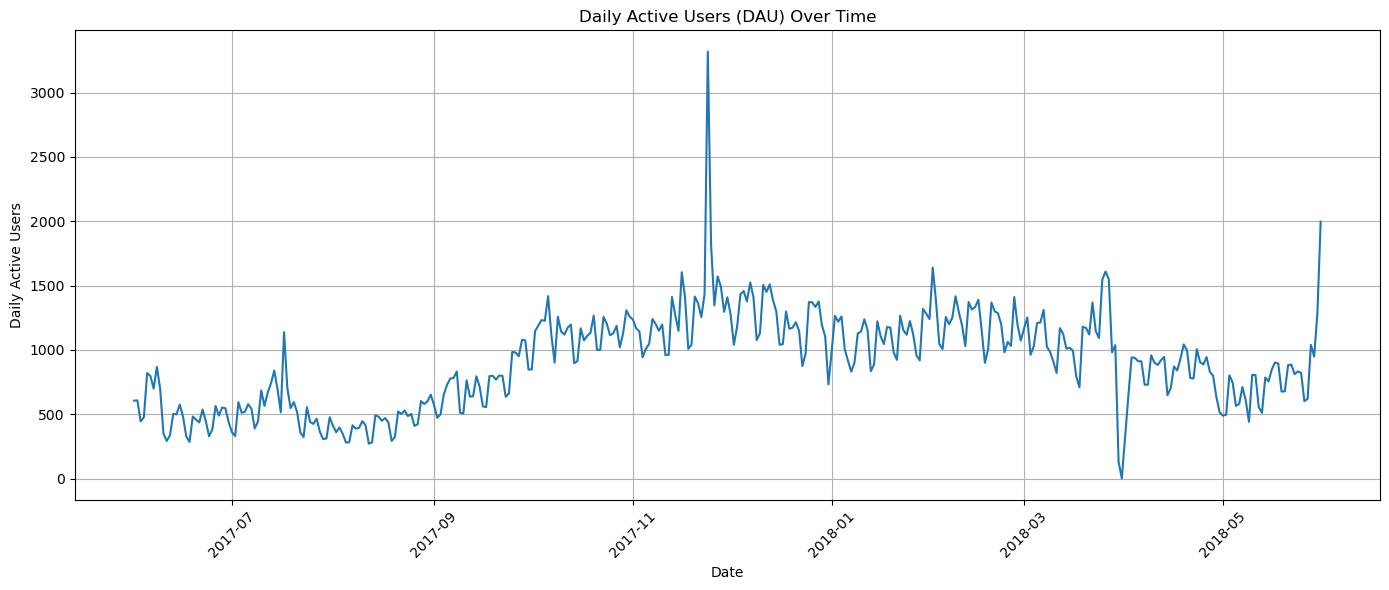

In [15]:
plt.figure(figsize=(14,6))
plot = sns.lineplot(data=dua, x='session_date', y='daily_active_users')
plot.set_title('Daily Active Users (DAU) Over Time')
plt.xticks(rotation=45)
plt.ylabel('Daily Active Users')
plt.xlabel('Date')
plt.tight_layout()
plt.grid()
plt.show() 

La gráfica de usuarios activos diarios (DAU) a lo largo del tiempo muestra una tendencia de crecimiento con fluctuaciones, reflejando un comportamiento dinámico de la comunidad. Se observan picos destacados en noviembre de 2017 y junio de 2018, lo que sugiere la influencia de eventos específicos como lanzamientos, campañas o actualizaciones que impulsaron la participación. Las variaciones periódicas también dejan entrever posibles patrones estacionales vinculados a ciclos de consumo, como vacaciones o fin de año. A pesar de las caídas en ciertos periodos, la base de usuarios se mantiene estable y con capacidad de respuesta, lo que evidencia un nivel sostenido de engagement. En conjunto, la gráfica indica que el crecimiento de usuarios no es lineal, sino que depende de momentos clave y factores externos, información valiosa para identificar oportunidades estratégicas y maximizar el impacto de futuras acciones de marketing o producto.

#### ¿Cuántas sesiones hay por día?

In [16]:
# Cálculo del número de sesiones por usuario
daily_sessions = visits.groupby(['session_year','session_month','session_date']).agg({'uid':['count','nunique']}).reset_index()
daily_sessions.columns = ['session_year','session_month','session_date','n_sessions','n_users']
daily_sessions['sessions_per_user'] = daily_sessions['n_sessions'] / daily_sessions['n_users']
# Cálculo del número promedio de sesiones por usuario y por día en el mes
montly_sessions = daily_sessions.groupby(['session_year','session_month']).agg({'sessions_per_user':'mean','n_sessions':'mean'}).reset_index()
montly_sessions.columns = ['session_year','session_month','avg_sessions_per_user_in_month','avg_sessions_per_day_in_month']

In [17]:
# Promedio de inicios de sesión por usuario
print('Promedio de inicios de sesión por usuario:',montly_sessions['avg_sessions_per_user_in_month'].mean())

Promedio de inicios de sesión por usuario: 1.0822094906655846


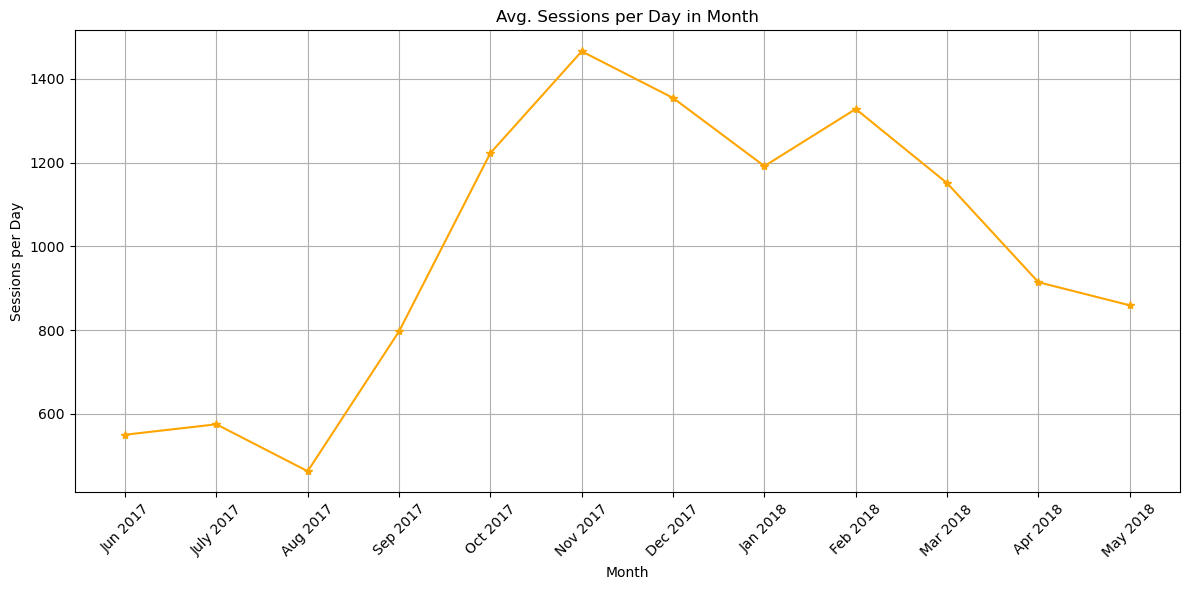

In [18]:
# Análisis de las sesiones promedio por usuario por mes
fig, ax = plt.subplots(figsize=(12, 6))
montly_sessions.sort_values(by=['session_year','session_month'], inplace=True)
montly_sessions.plot(y='avg_sessions_per_day_in_month', 
                     kind='line', 
                     title='Avg. Sessions per Day in Month',
                     color='orange',
                     rot=45,
                     marker='*',
                     ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.ylabel('Sessions per Day')
plt.xlabel('Month')
plt.legend().remove()
plt.tight_layout()
plt.grid()
plt.show()

Con base en los cálculos, el promedio obtenido de usuarios que inician sesión es de 1 sesión por usuario. Si bien el hecho de que solo tengan una sesión podría considerarse algo negativo, aún sería necesario contrastar esta información con las ganancias obtenidas de los usuarios y el tiempo que permanecen dentro de las sesiones, ya que probablemente en una sola sesión se realicen compras de boletos para diferentes eventos o incluso adquisiciones de gran cantidad de boletos (actividades que suelen realizar los revendedores).

Por otro lado, también se cuenta con la tabla que indica el promedio de sesiones por día realizadas en cada mes. Como es fácil observar, la tendencia de los datos comienza a incrementarse en las épocas cercanas a las fechas navideñas y de fin de año, lo cual podría significar que se realizan compras para regalos navideños o para otros eventos importantes del siguiente año.

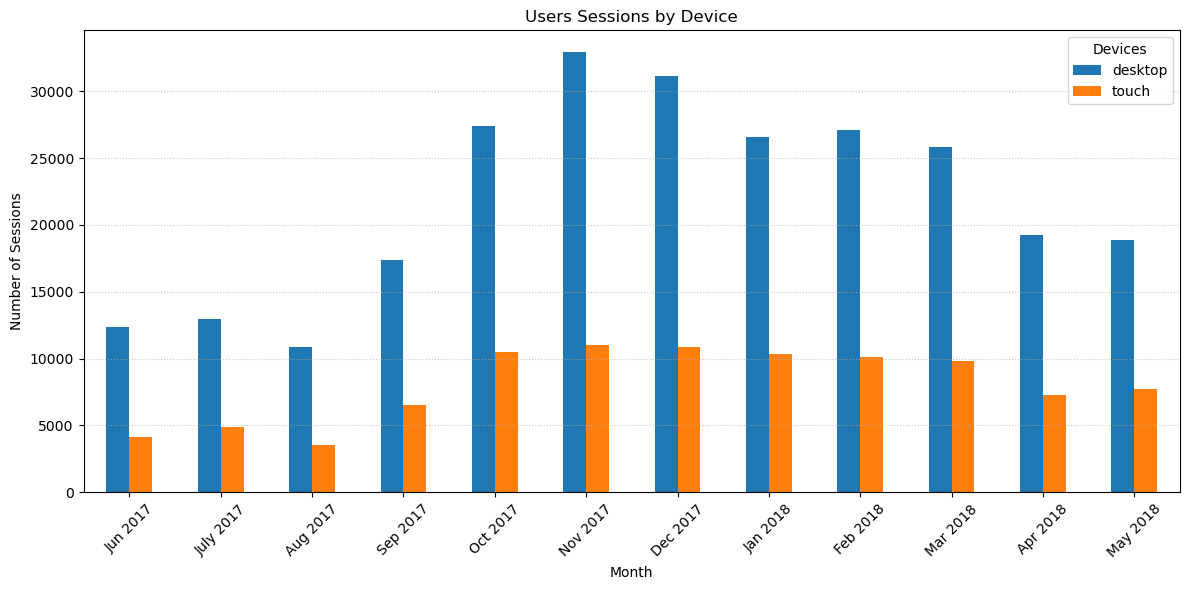

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
visits_devices = visits.groupby(['session_year','session_month','device']).agg({'uid':'count'}).reset_index()
visits_devices.columns = ['session_year','session_month','device','n_users']    
visits_devices.sort_values(by=['session_year','session_month'], inplace=True)
pivot_devices = visits_devices.pivot(index=['session_year','session_month'], columns='device', values='n_users').reset_index()
pivot_devices.plot(x='session_month', 
                   y=['desktop','touch'], 
                   kind='bar', 
                   title='Users Sessions by Device',
                   rot=45,
                   ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title='Devices')
plt.ylabel('Number of Sessions')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

De acuerdo con la gráfica de los usuarios por dispositivo, se observa una clara dominancia de los usuarios que utilizan dispositivos denominados desktop (muy probablemente computadoras) sobre aquellos que emplean dispositivos touch (como móviles o tabletas). Esto puede implicar dos escenarios: por un lado, que la plataforma de Showz únicamente cuente con un portal web al cual los usuarios acceden independientemente del dispositivo; o bien, que si la plataforma dispone de una aplicación móvil, esta no sea lo suficientemente popular o intuitiva como para que los usuarios prefieran acceder mediante dispositivos móviles

#### ¿Cuál es la duración de cada sesión?

In [20]:
# Cálclo de la duración promedio de las sesiones
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
avg_session_duration = visits['session_duration'].mean()  
print(f'La duración promedio de las sesiones es: {avg_session_duration:.2f} segundos')

La duración promedio de las sesiones es: 643.03 segundos


Según el promedio de la duración de las sesiones, estas tienen una duración aproximada de 10 a 11 minutos. Esto podría indicar que probablemente se realizan más de una operación por sesión; sin embargo, también es necesario considerar factores como posibles errores en la plataforma, un diseño poco intuitivo o el uso del servicio para compras de gran volumen.

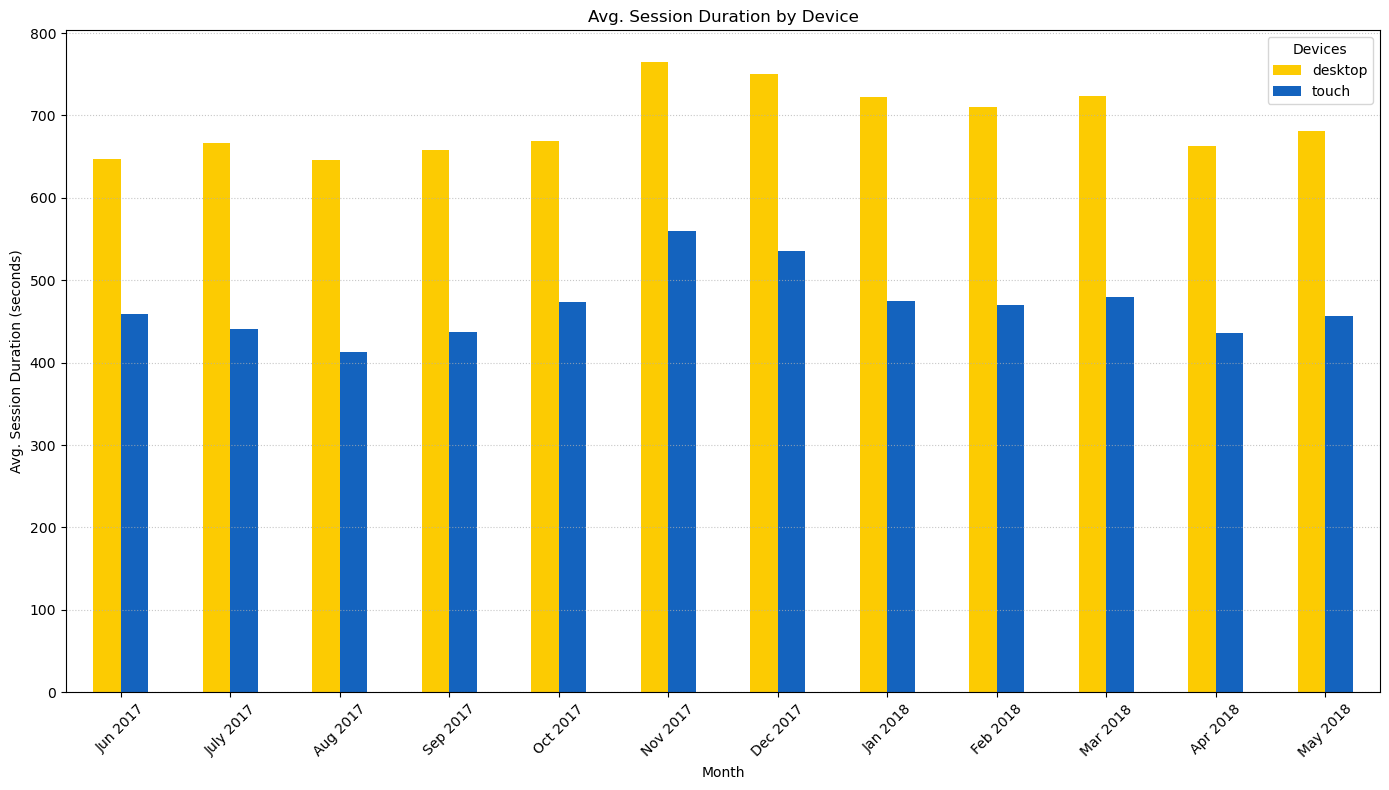

In [21]:
fig, ax = plt.subplots(figsize=(14, 8)) 
devices_duraton = visits.groupby(['session_year','session_month','device']).agg({'session_duration':'mean'}).reset_index()
devices_duraton.columns = ['session_year','session_month','device','avg_session_duration']
pivot_devices_duration = devices_duraton.pivot(index=['session_year','session_month'], columns='device', values='avg_session_duration').reset_index()
pivot_devices_duration.plot(x='session_month', 
                            y=['desktop','touch'], 
                            kind='bar', 
                            title='Avg. Session Duration by Device', 
                            color=['#FCCB02',"#1463BE"],
                            rot=45,
                            ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title='Devices')
plt.ylabel('Avg. Session Duration (seconds)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

En perspectiva, se observa que la duración de las sesiones por dispositivo sigue siendo predominante en los dispositivos desktop frente a los dispositivos touch. Sin embargo, la diferencia en la duración de las sesiones no es tan grande, lo que puede significar que, aunque los usuarios prefieren acceder mediante la página web en dispositivos considerados desktop, también existe cierta comodidad en el uso de dispositivos touch. Si bien lo anterior es una hipótesis, sería necesario comparar estos resultados con otros datos para identificar la posible causa de que los dispositivos touch sean los menos frecuentes para acceder a la plataforma de compra de boletos.

#### ¿Con qué frecuencia los usuarios regresan?

In [22]:
# Clculo del factor de adherencia por semana
sticky_wau = (dua_total / wua_total) * 100
print(f'Frecuencia con la que regresan los usuarios a la semana es de: {sticky_wau:.2f}%')
# Clculo del factor de adherencia por mes
sticky_mau = (dua_total / mua_total) * 100
print(f'Frecuencia con la que regresan los usuarios al mes es de: {sticky_mau:.2f}%')

Frecuencia con la que regresan los usuarios a la semana es de: 15.59%
Frecuencia con la que regresan los usuarios al mes es de: 3.91%


El factor de adherencia es bastante bajo tanto a la semana como al mes. En términos más prácticos, se puede decir que semanalmente solo alrededor de 15 usuarios de cada 100 regresan a utilizar la plataforma, y mensualmente únicamente entre 3 y 4 de cada 100 lo hacen. Esta cantidad resulta absurdamente baja si se considera que las métricas de DAU, WAU y MAU son elevadas. Esto significa que, aunque se captan muchos usuarios nuevos a lo largo del año, solo una pequeña proporción vuelve a hacer uso del servicio. En consecuencia, los usuarios muestran un comportamiento muy casual y tienden a presentarse únicamente en determinadas temporadas.

### 💲 Ventas

#### ¿Cuándo empieza la gente a comprar?

In [23]:
# Agrupación por mes de la primera visita y primer pedido
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid','first_visit']
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid','first_order']

# Cración del dataframe user_journey y cálculo de los días hasta la conversión y el mes y año del primer pedido
user_journey = first_visit.merge(first_order, on='uid', how='outer')
user_journey['days_to_conversion'] = (user_journey['first_order'] - user_journey['first_visit']).dt.days
user_journey['first_order_month'] = user_journey['first_order'].dt.month
user_journey['first_order_year'] = user_journey['first_order'].dt.year

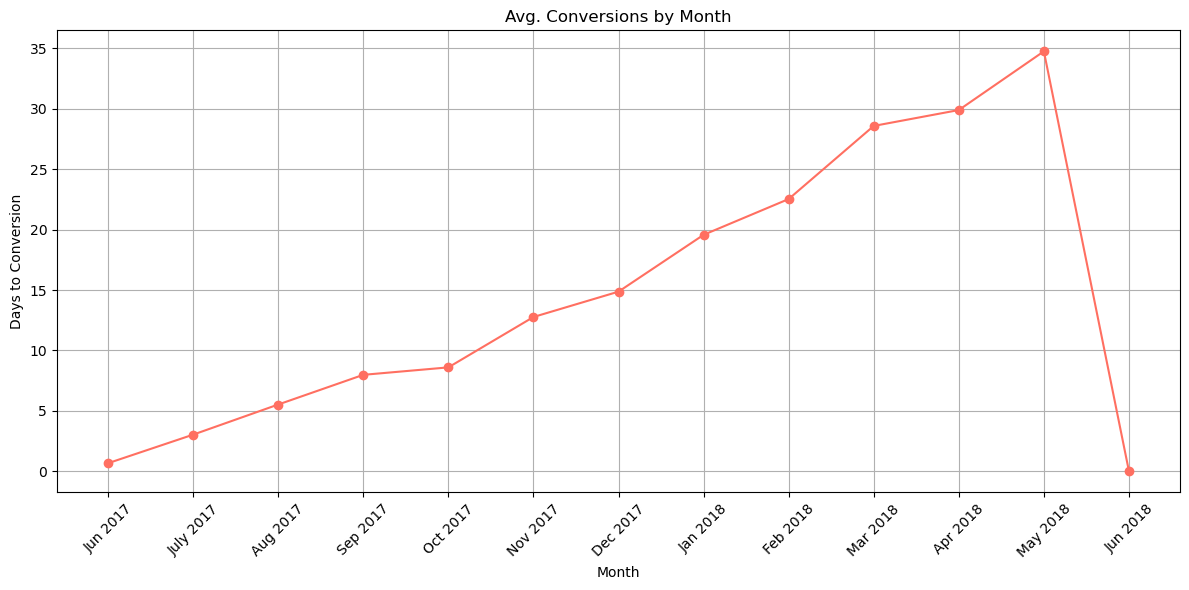

In [24]:

# Agrupación por mes y año de la primera visita y cálculo del promedio de días hasta la conversión
conversion_by_month = user_journey.groupby(['first_order_year','first_order_month']).agg({'days_to_conversion':'mean'}).reset_index()
conversion_by_month.columns = ['first_order_year','first_order_month','avg_days_to_conversion'] 
conversion_by_month.sort_values(by=['first_order_year','first_order_month'], inplace=True)

# Graficación de las conversiones por mes a lo largo del año
fig, ax = plt.subplots(figsize=(12, 6))
conversion_by_month.plot(y='avg_days_to_conversion', 
                         kind='line', 
                         title='Avg. Conversions by Month',
                         rot=45, marker='o',
                         color='#FF6F61',
                         ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018','Jun 2018'])
plt.ylabel('Days to Conversion')
plt.xlabel('Month')
plt.legend().remove()
plt.tight_layout()
plt.grid()
plt.show()

La gráfica muestra un comportamiento alarmante por parte de los usuarios, ya que conforme pasa el tiempo tardan más en convertirse en clientes de la plataforma Showz. Este comportamiento resulta sumamente negativo, pues genera diversos factores que afectan tanto las inversiones como los ingresos de la plataforma. A medida que el tiempo de conversión aumenta, existe una alta probabilidad de que los usuarios opten por la competencia, el costo de adquisición por cliente se incrementa y, aunado a los bajos niveles de adherencia, las ganancias se mantienen demasiado bajas.

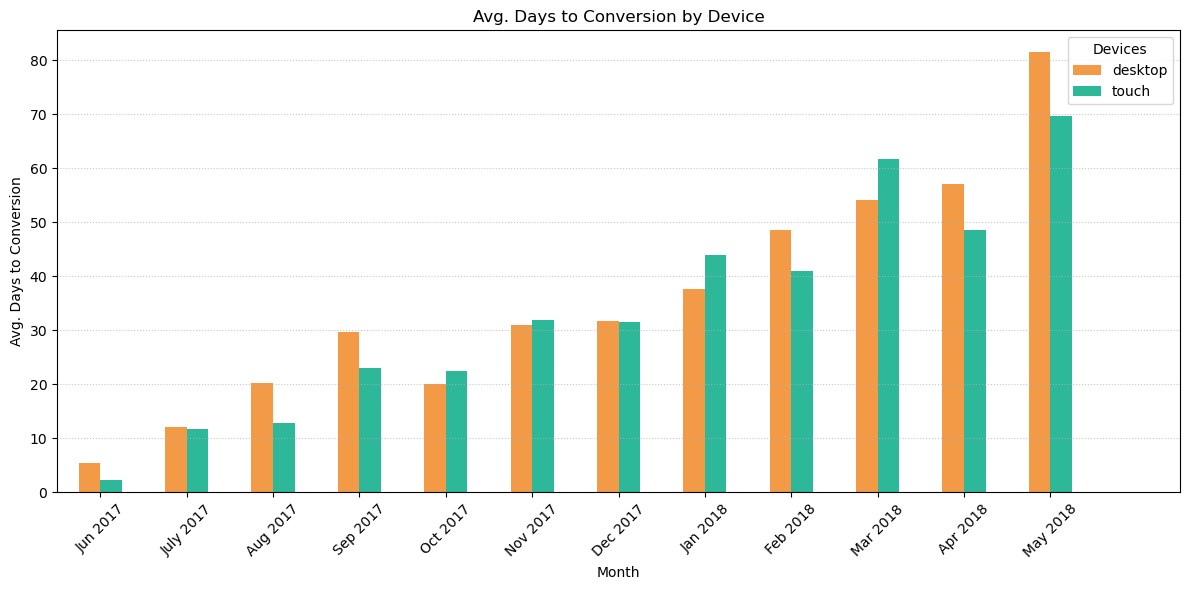

In [25]:
uid_devices = visits[['uid','device']]
uid_devices = user_journey.merge(uid_devices, on='uid', how='left')
conversion_by_device = uid_devices.groupby(['first_order_year','first_order_month','device']).agg({'days_to_conversion':'mean'}).reset_index()
pivot_devices_duration = conversion_by_device.pivot_table(index=['first_order_year','first_order_month'], columns='device', values='days_to_conversion', aggfunc='sum').reset_index().fillna(0)
fig, ax = plt.subplots(figsize=(12, 6))
pivot_devices_duration.plot(x='first_order_month', 
                            y=['desktop','touch'], 
                            kind='bar', 
                            title='Avg. Days to Conversion by Device', 
                            color=["#F39A47","#2EB89A"],
                            rot=45,
                            ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title='Devices')
plt.ylabel('Avg. Days to Conversion')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

Como se puede observar en la gráfica, la mayor cantidad de días de conversión proviene de los dispositivos desktop y no de los dispositivos touch, como podría pensarse. Esto deja entrever ciertas posibilidades: la interfaz para usuarios de dispositivos desktop podría ser poco intuitiva o poco clara al momento de realizar compras en comparación con la versión para dispositivos touch; probablemente resulta más sencillo comprar desde la comodidad de un dispositivo touch en cualquier momento y lugar; y, por último, el marketing dirigido a dispositivos touch podría ser más eficiente que el orientado a dispositivos desktop.

#### ¿Cuántos pedidos hacen durante un período de tiempo dado?

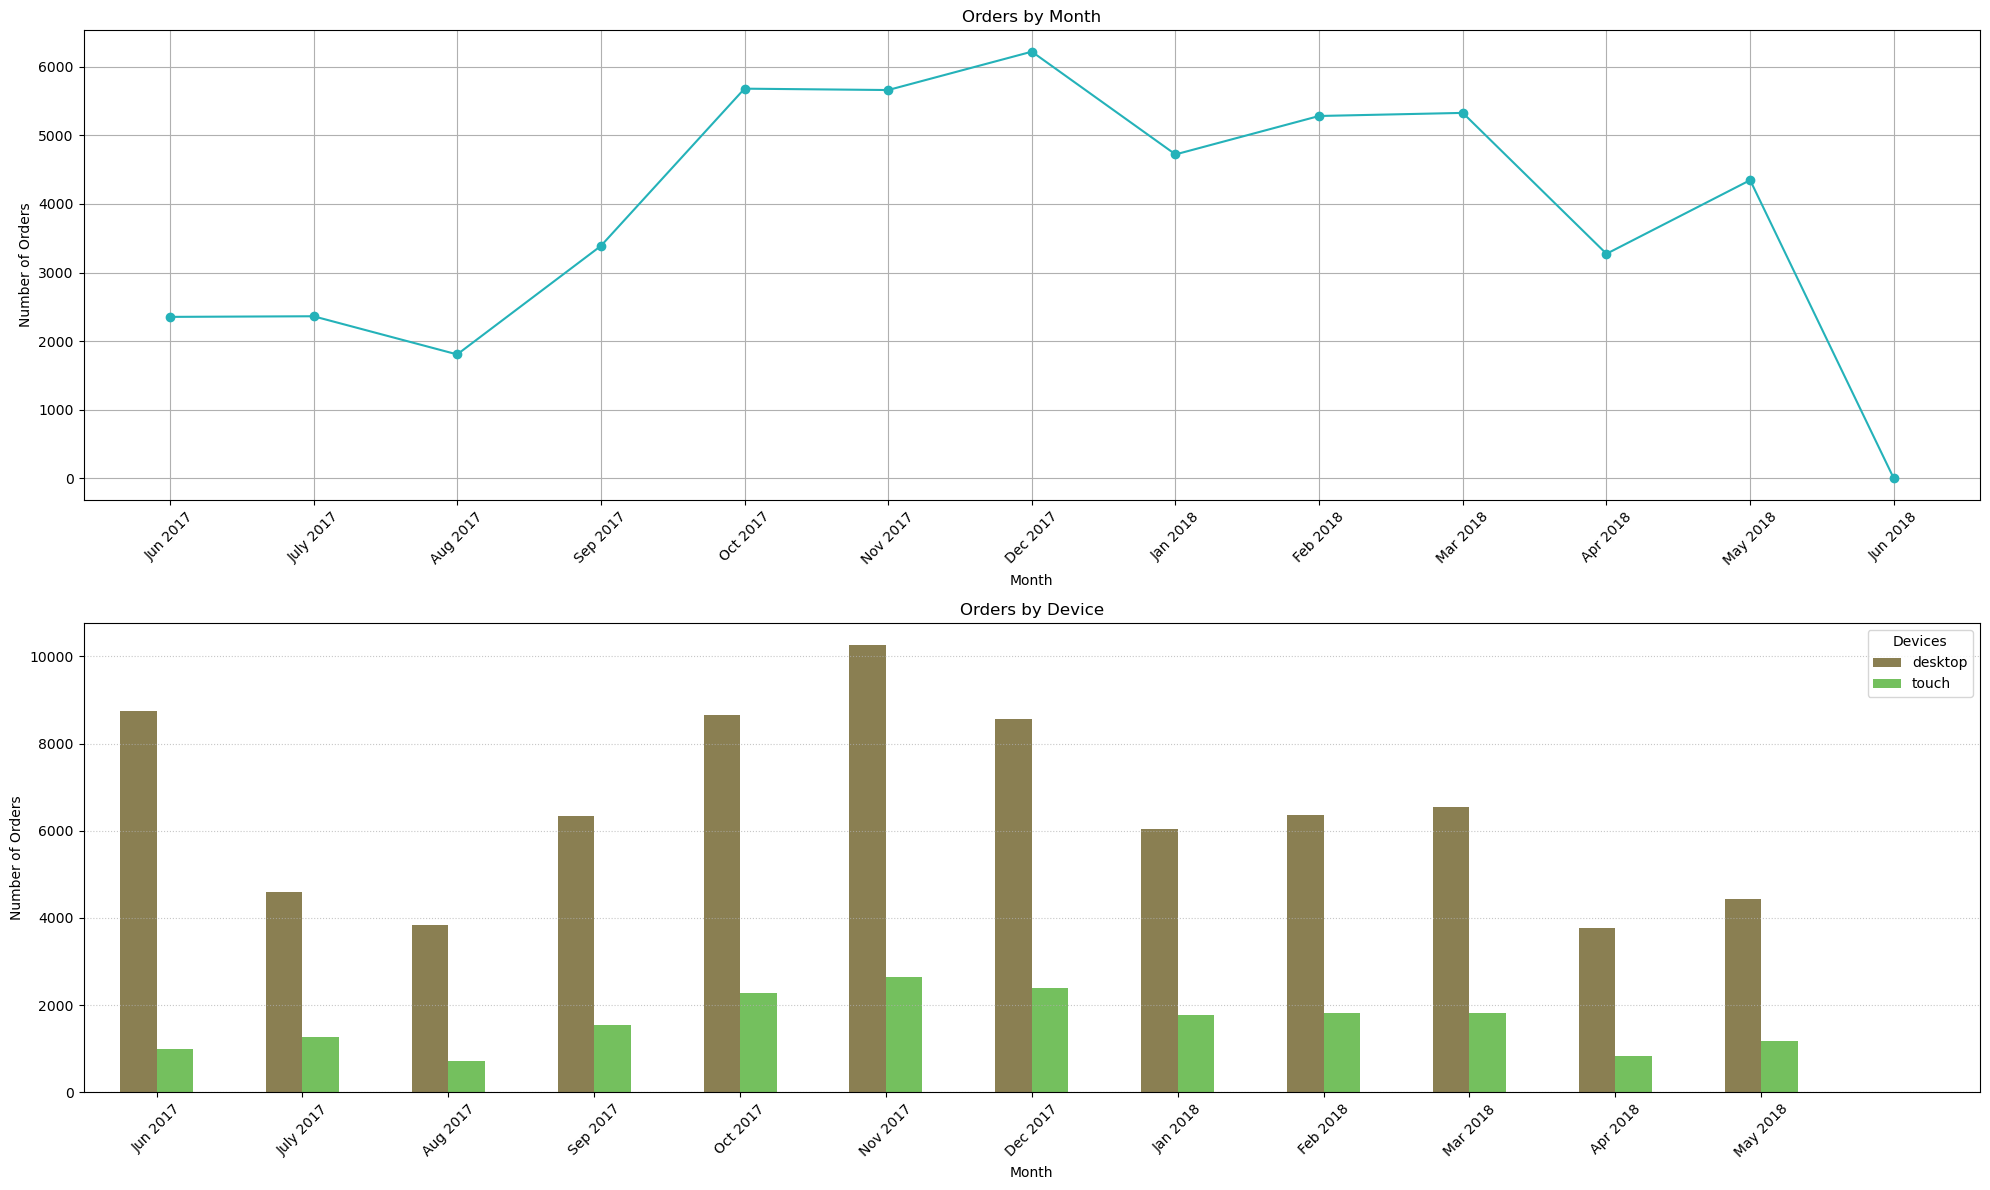

In [26]:
orders['order_month'] = orders['buy_ts'].dt.month
orders['order_year'] = orders['buy_ts'].dt.year
orders_number = orders.groupby(['order_year','order_month']).agg({'uid':'count'}).reset_index()
orders_number.columns = ['order_year','order_month','n_orders']
orders_number.sort_values(by=['order_year','order_month'], inplace=True)

# --- Segundo gráfico: pedidos por dispositivo ---
orders_by_device = uid_devices.groupby(['first_order_year','first_order_month','device']).agg({'uid':'count'}).reset_index()
orders_by_device.columns = ['first_order_year','first_order_month','device','n_orders']
pivot_orders_by_device = orders_by_device.pivot_table(
    index=['first_order_year','first_order_month'],
    columns='device',
    values='n_orders',
    aggfunc='sum'
).reset_index().fillna(0)

# Crear figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(2, 1, figsize=(20, 12))

# --- Subplot 1: línea de pedidos por mes ---
orders_number.plot(
    y='n_orders',
    kind='line',
    title='Orders by Month',
    rot=45,
    color="#24B2B9",
    marker='o',
    ax=axs[0]
)
axs[0].set_xticks(range(13))
axs[0].set_xticklabels(['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017',
                        'Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018','Jun 2018'],
                       rotation=45)
axs[0].set_ylabel('Number of Orders')
axs[0].set_xlabel('Month')
axs[0].legend().remove()
axs[0].grid()

# --- Subplot 2: barras por dispositivo ---
pivot_orders_by_device.plot(
    x='first_order_month',
    y=['desktop','touch'],
    kind='bar',
    title='Orders by Device',
    color=["#8A7F52","#74C05E"],
    rot=45,
    ax=axs[1]
)
axs[1].set_xticks(range(12))
axs[1].set_xticklabels(['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017',
                        'Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'],
                       rotation=45)
axs[1].set_ylabel('Number of Orders')
axs[1].set_xlabel('Month')
axs[1].legend(title='Devices')
axs[1].grid(axis='y', linestyle=':', alpha=0.7)

# Ajustar espacios y mostrar
plt.tight_layout()
plt.show()

Se puede observar que la cantidad de pedidos comienza a repuntar en agosto de 2017 y alcanza su punto más bajo en abril de 2018. Esto muestra que existe una tendencia por parte de los usuarios que inicia en agosto, probablemente debido a la presencia de más ofertas o al inicio de la venta de eventos importantes y populares en esas fechas.

Si bien la tendencia sigue predominando en los dispositivos desktop, hay un aspecto importante que puntualizar respecto a la gráfica mostrada. En la tabla de conversiones se observó que en algunos meses los dispositivos touch superaron en número de conversiones a los desktop. Lo anterior plantea una pregunta relevante: ¿acaso los dispositivos touch tienen un potencial que no ha sido explotado para la atracción, venta y retención de usuarios? Si nos enfocamos en el mes de marzo en ambas gráficas, podemos ver que, a pesar de que se realizaron pocas órdenes mediante dispositivos touch, fue el mes en el que mayor cantidad de usuarios se convirtieron en clientes. Este detalle no es insignificante, ya que evidencia un potencial poco aprovechado

#### ¿Cuál es el tamaño promedio de compra?

In [27]:
# Agrupación por mes y año del pedido y cálculo del ingreso promedio por pedido
mean_purchase = orders.groupby(['order_year','order_month']).agg({'revenue':'mean'}).reset_index()
mean_purchase.columns = ['order_year','order_month','mean_revenue']
mean_purchase.sort_values(by=['order_year','order_month'], inplace=True)

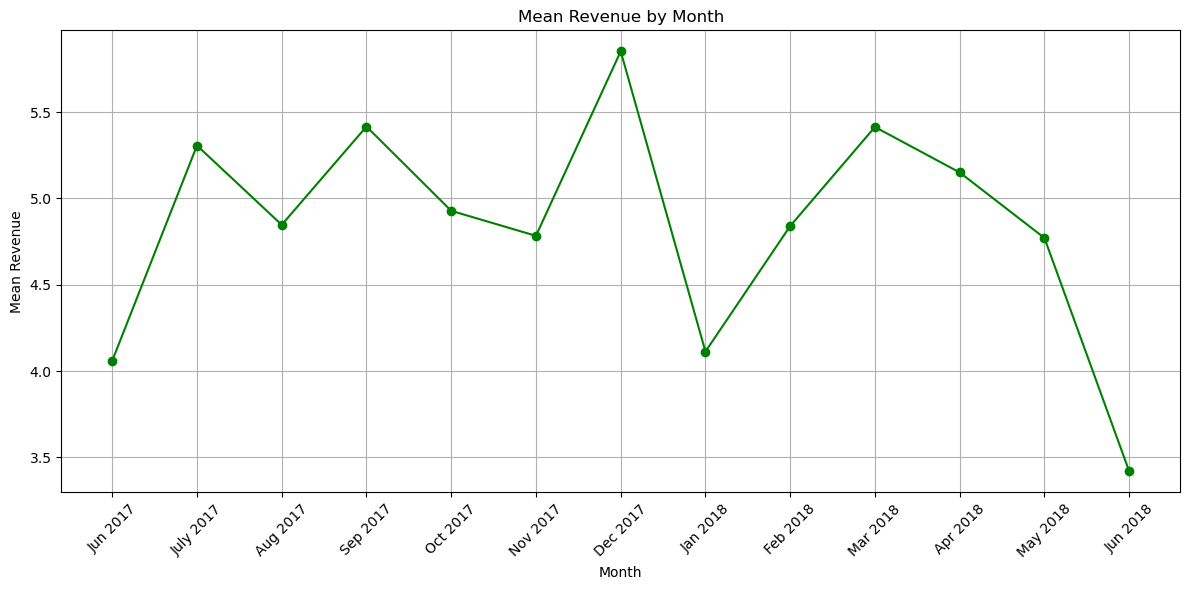

In [28]:
# Graficación del ingreso promedio por pedido a lo largo del año
fig, ax = plt.subplots(figsize=(12, 6))  # ancho=12, alto=6
mean_purchase.plot(y='mean_revenue',
                   kind='line',
                   title='Mean Revenue by Month',
                   color='green',
                   rot=45,
                   marker='o',
                   ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018','Jun 2018'])
plt.legend().remove()
plt.ylabel('Mean Revenue')
plt.xlabel('Month')
plt.grid()
plt.tight_layout()
plt.show()

La gráfica anterior muestra el promedio de ganancias a lo largo del año por cada mes. Un aspecto importante a puntualizar es que, en este caso, el repunte de ingresos no comienza de manera tan marcada en agosto, a pesar de que en la tabla anterior es cuando se observa un incremento en el número de órdenes. Aquí, el punto con mayores ingresos promedio corresponde al mes de diciembre, lo cual coincide con la temporada navideña identificada en un análisis previo. A partir de este máximo, se observa que en los primeros meses del año los ingresos caen abruptamente, lo cual resulta comprensible, ya que la mayoría de las personas que realizaron compras navideñas y de fin de año no suelen mantener el mismo nivel de gasto al inicio del siguiente año.

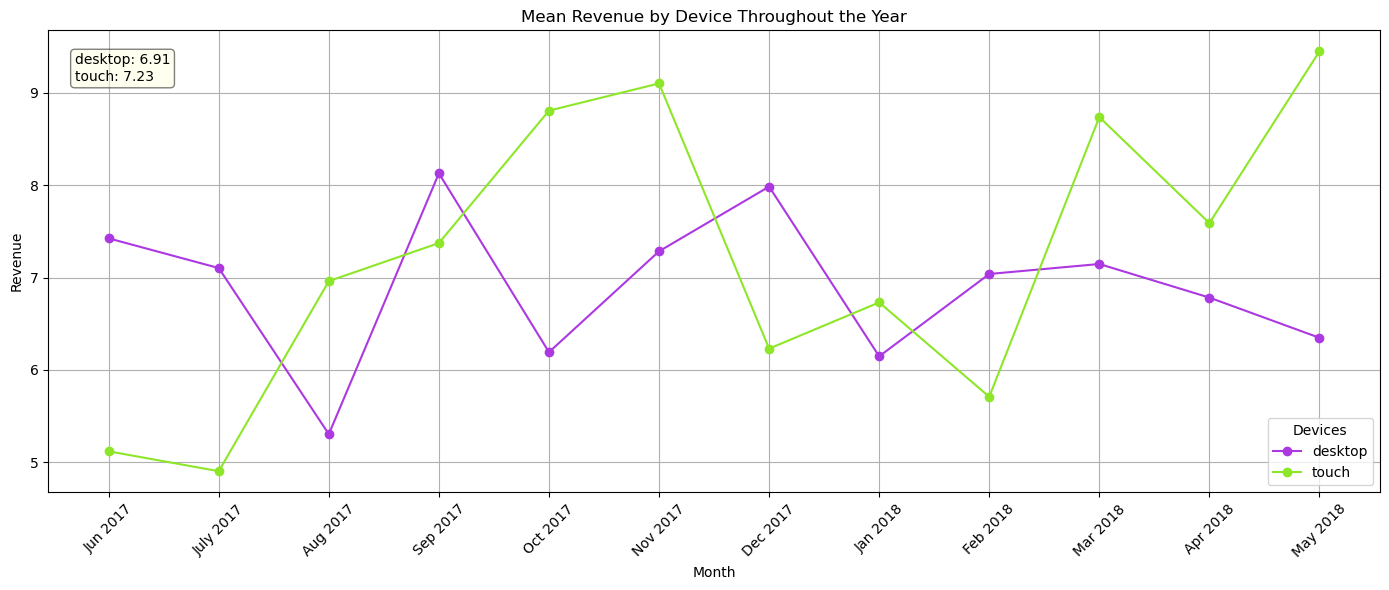

In [29]:
customers = visits.groupby('source_id').agg({'uid':'nunique'}).reset_index().sort_values(by='uid', ascending=False)
customers.columns = ['source_id','n_customers']

devices_purchase = visits[['uid','source_id','session_year','session_month','device']].merge(
    orders[['uid','revenue']], on='uid'
)

revenue_by_purchase = devices_purchase.groupby(
    ['session_year','session_month','source_id','device']
).agg({'revenue':'mean'}).reset_index()

revenue_by_purchase.sort_values(by=['session_year','session_month'], inplace=True)
revenue_by_purchase = revenue_by_purchase.merge(customers[['source_id','n_customers']], on='source_id')

# --- Pivot para graficar ---
fig, ax = plt.subplots(figsize=(14, 6))
revenue = revenue_by_purchase.pivot_table(
    index=['session_year','session_month'],
    columns='device',
    values='revenue',
    aggfunc='mean'
).reset_index().fillna(0)

# Graficación
revenue.iloc[:,2:].plot(
    kind='line',
    title='Mean Revenue by Device Throughout the Year',
    color=["#AC38E2","#8EE629"],
    rot=45,
    marker='o',
    ax=ax
)

plt.xticks(
    [0,1,2,3,4,5,6,7,8,9,10,11],
    labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017',
            'Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018']
)
plt.legend(title='Devices')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.grid()
plt.tight_layout()

# --- Calcular promedio total por dispositivo ---
mean_revenues = revenue.iloc[:,2:].mean()

# --- Añadir texto con los promedios ---
text_str = "\n".join([f"{device}: {value:.2f}" for device, value in mean_revenues.items()])
ax.text(
    0.02, 0.95, text_str,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.5)
)

plt.show()


De acuerdo con la tabla, se observa que el promedio de ingresos por dispositivo es mayor en los dispositivos touch que en los desktop. Si bien la diferencia es mínima, existe, aunque también deben considerarse otros factores que afectan las demás métricas que se analizarán posteriormente. Lo que sí cabe puntualizar es la gran fluctuación en las ganancias de ambos dispositivos: se nota que son muy inestables y tienden a subir y bajar con el tiempo, sin mantenerse constantes. En algunos puntos específicos se identifican tendencias al alza, pero también las hay a la baja. Tal comportamiento refleja una marcada inestabilidad en las ganancias, lo cual resulta poco favorable si se considera que es necesario obtener un retorno de inversión consistente para que el negocio continúe funcionando y sea rentable.

#### ¿Cuánto dinero traen? (LTV)

In [30]:
# Agrupación por mes y año del primer pedido y conteo del número de usuarios que realizaron su primer pedido en ese mes
orders['date_order'] = orders['buy_ts'].dt.to_period('M')
mainly_orders = orders.groupby('uid').agg({'date_order':'min'}).reset_index()
mainly_orders.columns = ['uid','first_order_month']
cohort_sizes = mainly_orders.groupby('first_order_month').agg({'uid':'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month','n_users']

In [31]:
# Combinación de los dataframes orders y mainly_orders para obtener el mes del primer pedido de cada usuario
orders_ltv = pd.merge(orders, mainly_orders, on='uid')
# Cálculo de los ingresos totales por mes de la primera compra y del mes del pedido
cohort = orders_ltv.groupby(['first_order_month','date_order']).agg({'revenue':'sum'}).reset_index()
report = pd.merge(cohort_sizes, cohort, on='first_order_month')

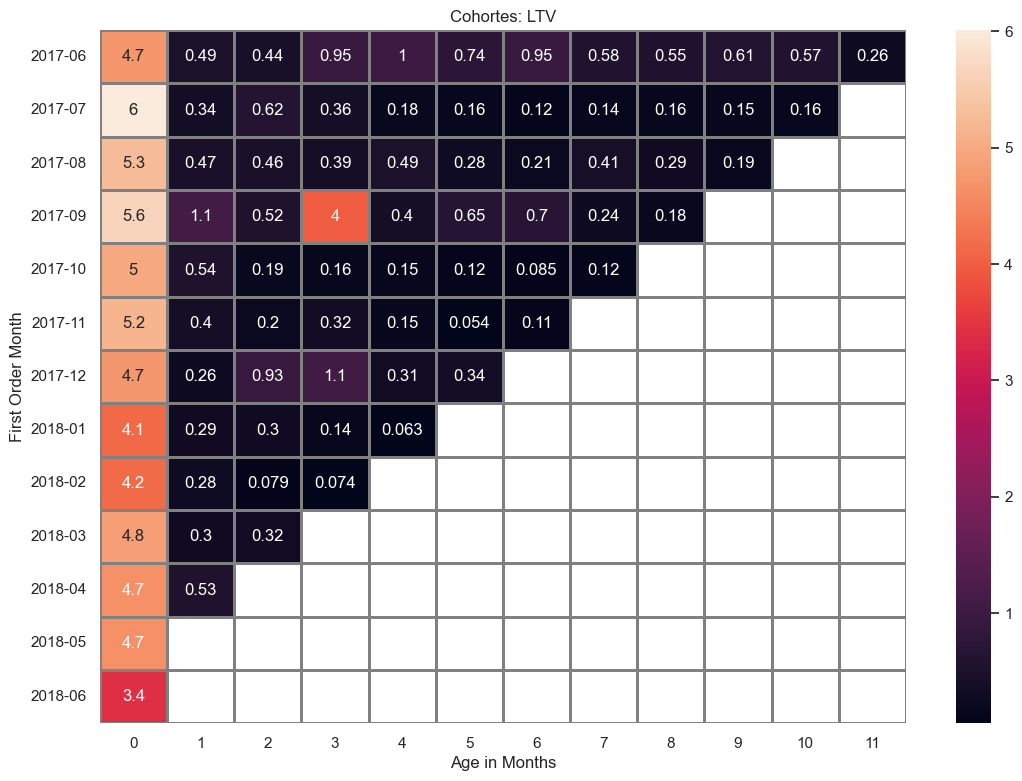

In [32]:
# Se propone un margen de ganancia del 100%
margin_rate = 1
report['gross_profit'] = report['revenue'] * margin_rate
report['age_in_months'] = (report['date_order'] - report['first_order_month']).apply(lambda x: x.n)
report['ltv'] = report['gross_profit'] / report['n_users']
ltv_cohort = report.pivot_table(index='first_order_month', columns='age_in_months', values='ltv', aggfunc='mean')
ltv_cohort.fillna('')

sns.set_theme(style='white')
plt.figure(figsize=(13, 9))
plt.title('Cohortes: LTV')
sns.heatmap(
    ltv_cohort, 
    annot=True, 
    linewidths=1, 
    linecolor='gray')
plt.ylabel('First Order Month')
plt.xlabel('Age in Months')
plt.show()

Además de evidenciar que los ingresos nunca vuelven a alcanzar los niveles iniciales del ciclo, la gráfica muestra que el valor de vida del cliente (LTV) decrece de manera abrupta después del primer mes en prácticamente todas las cohortes. Esto indica que los usuarios generan la mayor parte de sus ingresos en el momento de su primera compra y que la retención es mínima, lo cual limita el potencial de monetización a largo plazo.

También se observa que, aunque algunas cohortes presentan ligeros repuntes en meses posteriores (por ejemplo, septiembre 2017 con un valor relativamente alto en el mes 3), estos son casos aislados y no representan una tendencia sostenida. La inestabilidad en los valores sugiere que no existe una estrategia clara para fomentar la recurrencia de compras.

En términos estratégicos, esto implica que el negocio depende en gran medida de la adquisición constante de nuevos clientes, lo cual incrementa los costos de marketing y reduce la rentabilidad. Para mejorar este panorama, sería necesario implementar acciones que fortalezcan la fidelización, como programas de recompensas, promociones personalizadas o mejoras en la experiencia de usuario que incentiven la recompra.


### 📉 Marketing

#### ¿Cuánto dinero se gastó?

In [33]:
# Creación de la tabla de costos mensuales totales y su suma anual
costs['session_month'] = costs['dt'].dt.month
costs['session_year'] = costs['dt'].dt.year
monthly_total_costs = costs.groupby(['session_year','session_month']).agg({'costs':'sum'}).reset_index()
monthly_total_costs.columns = ['session_year','session_month','total_cost_per_month']
print('Costo total en el año es: $', monthly_total_costs['total_cost_per_month'].sum())

Costo total en el año es: $ 329131.62


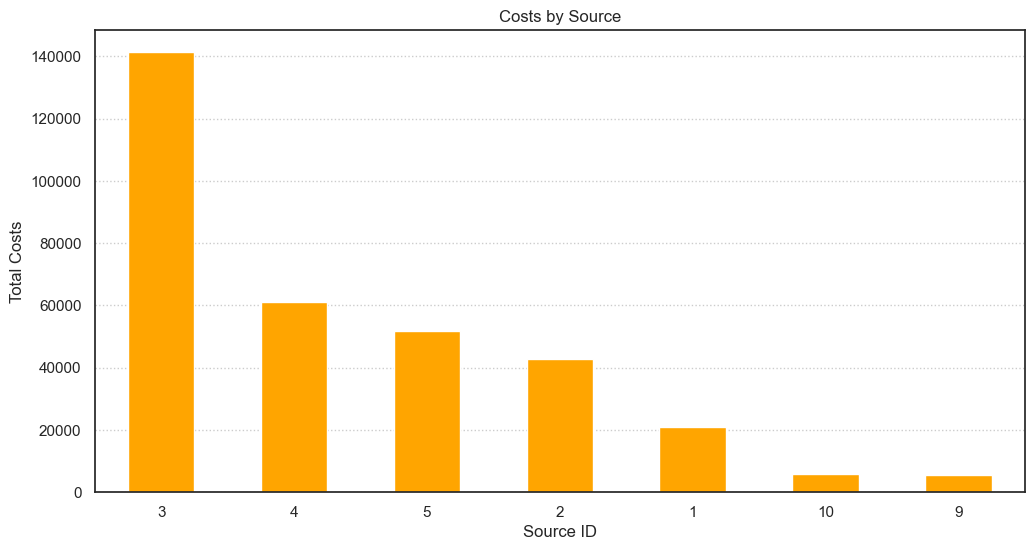

In [34]:
# Creación de gráfico de costos por fuente
fig, ax = plt.subplots(figsize=(12, 6))  # ancho=12, alto=6
sources_costs = costs.groupby('source_id').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)
sources_costs.plot(x='source_id', 
                   y='costs', 
                   kind='bar', 
                   title='Costs by Source',
                   color='orange',
                   rot=0, 
                   ax=ax)
plt.grid(axis='y', linestyle=':')
plt.legend().remove()
plt.ylabel('Total Costs')
plt.xlabel('Source ID')
plt.show()

En consonancia con los resultados obtenidos, se observa que la inversión en la fuente de marketing número 3 es la mayor de todas. Esto podría deberse a que se trata de un canal de anuncios bastante popular, del cual se obtiene un alto volumen de usuarios que, en su mayoría, terminan convirtiéndose en clientes.

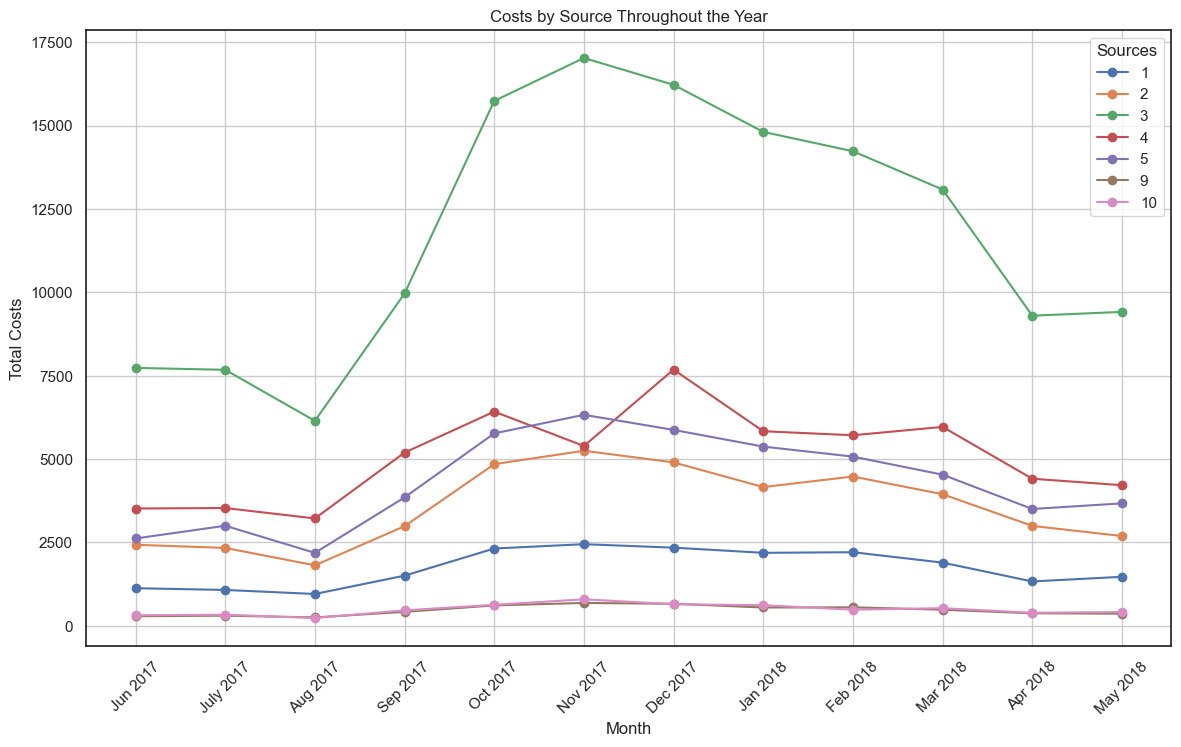

In [35]:
# Creación de gráfico de costos por fuente a lo largo del año
sources_costs_by_time = costs.groupby(['session_year','session_month','source_id']).agg({'costs':'sum'}).reset_index()
sources_costs_by_time.sort_values(by=['session_year','session_month'], inplace=True)

# Graficación de los costos de cada fuente de marketing a lo largo del año
fig, ax = plt.subplots(figsize=(14, 8))
sources = sources_costs_by_time.pivot(index=['session_year','session_month',], columns='source_id', values='costs').reset_index()
sources.iloc[:,2:].plot(kind='line', 
                        title='Costs by Source Throughout the Year', 
                        rot=45, 
                        marker='o',
                        ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Sources')
plt.ylabel('Total Costs')
plt.xlabel('Month')
plt.grid()
plt.show()

Conforme a lo mostrado en la sección anterior, se observa que los costos varían dependiendo de la fuente de marketing. En este caso particular, el canal de marketing correspondiente al ID 3 es el que presenta la mayor inversión a lo largo del tiempo. Además, se aprecia que las tendencias comienzan a repuntar en el mes de agosto, un comportamiento que ya se había identificado en análisis previos


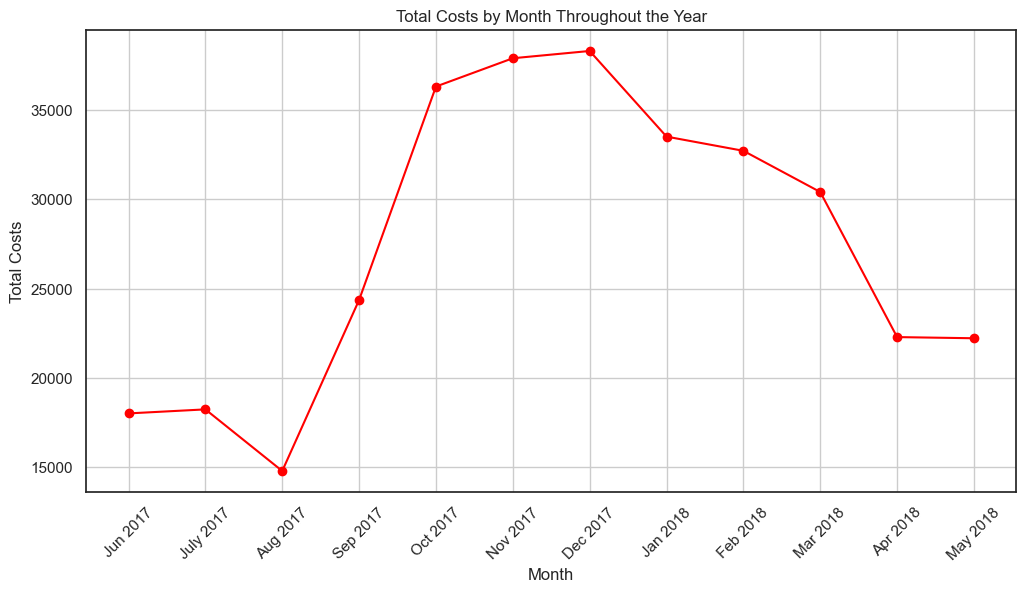

In [36]:
# Creación de gráfico de costos mensuales totales a lo largo del año
fig, ax = plt.subplots(figsize=(12, 6))
monthly_total_costs.sort_values(by=['session_year','session_month'], inplace=True)
monthly_total_costs.plot(y='total_cost_per_month', 
                         kind='line', 
                         title='Total Costs by Month Throughout the Year',
                         color='red', 
                         rot=45, 
                         marker='o',
                         ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend().remove()
plt.ylabel('Total Costs')
plt.xlabel('Month')
plt.grid()
plt.show()

Al igual que en la gráfica anterior, es muy notorio que el repunte comienza en el mes de agosto. Esto indica que tanto los ingresos como las inversiones dependen de temporadas. Si bien este comportamiento puede ser positivo, aún es necesario verificar cómo esos gastos se compensan con las ganancias obtenidas a lo largo del año. De nada sirve invertir grandes sumas de dinero si el retorno de esa inversión nunca llega.

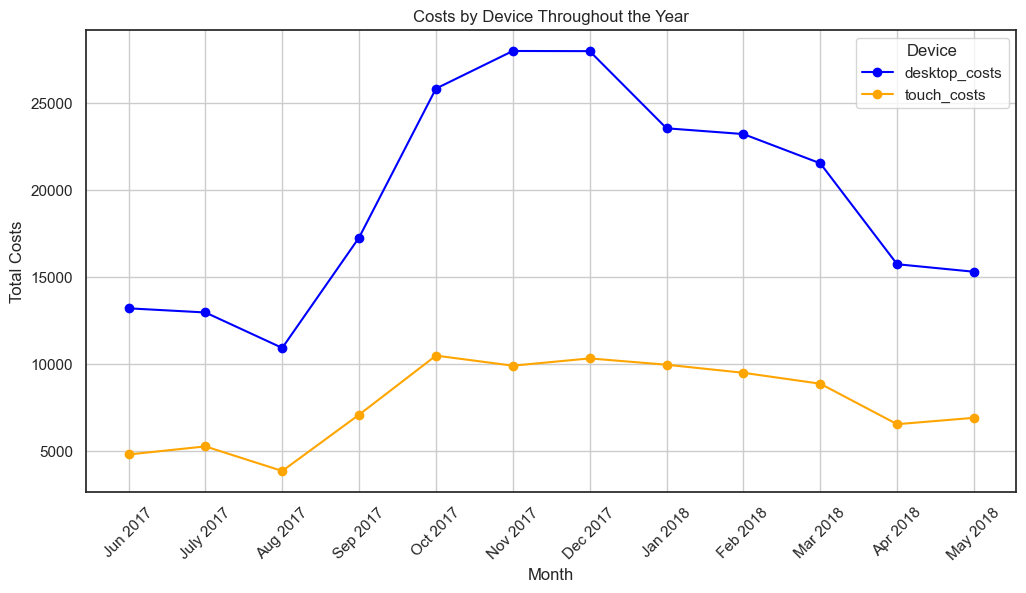

In [37]:
# Agrupación por mes y año del costo por dispositivo
devices = visits[['device','source_id','uid','session_month','session_year']]
devices = devices.groupby(['source_id','device','session_year','session_month']).agg({'uid':'nunique'}).reset_index()
devices.columns = ['source_id','device','session_year','session_month','n_devices']
pivot_dev = devices.pivot_table(index=['session_year','session_month'], columns='device', values='n_devices', aggfunc='sum').reset_index()
costs_by_devices = pivot_dev.merge(monthly_total_costs, on=['session_year','session_month'], how='inner')
costs_by_devices['desktop_costs'] = costs_by_devices['desktop'] * costs_by_devices['total_cost_per_month'] / (costs_by_devices['desktop'] + costs_by_devices['touch'])
costs_by_devices['touch_costs'] = costs_by_devices['touch'] * costs_by_devices['total_cost_per_month'] / (costs_by_devices['desktop'] + costs_by_devices['touch'])

# Graficación de los costos por dispositivo a lo largo del año
fig, ax = plt.subplots(figsize=(12, 6))
costs_by_devices.plot(y=['desktop_costs','touch_costs'], 
                      kind='line', 
                      title='Costs by Device Throughout the Year',
                      color=['blue','orange'], 
                      rot=45, 
                      marker='o', 
                      ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Device')
plt.ylabel('Total Costs')
plt.xlabel('Month')
plt.grid()
plt.show()

Como se puede observar, los dispositivos en los que recae mayormente el costo del marketing son los desktop, ya que son la principal vía utilizada por los usuarios para acceder a los canales de marketing. Es interesante notar que, a pesar de que el costo es total y no compartido, es posible calcular qué porcentaje de ese gasto se aprovecha en cada una de las fuentes. En este caso particular, cada dispositivo aprovecha la inversión realizada en marketing; sin embargo, se puede afirmar que quienes más lo aprovechan son los usuarios que ingresan a la plataforma mediante el dispositivo más recurrente, es decir, los desktop. No obstante, invertir un mayor presupuesto en marketing no necesariamente se traduce en mejores o mayores ganancias. En los siguientes puntos del proyecto se analizará si las inversiones realizadas son realmente redituables y, sobre todo, si están enfocadas en los sectores que más lo requieren.

#### ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes? 

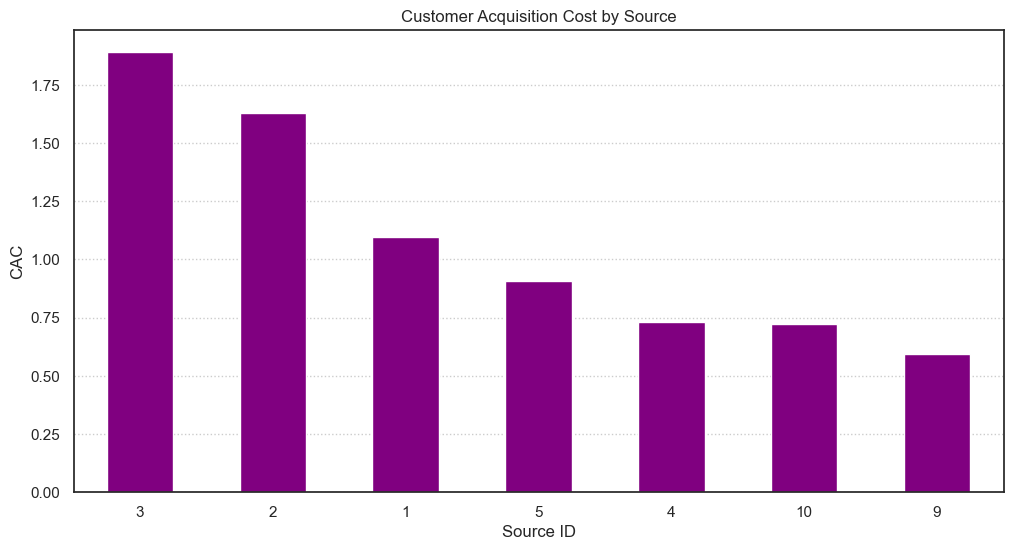

In [38]:
# Agrupación por fuente del primer pedido y conteo del número de usuarios que realizaron su primer pedido por fuente
costs_by_source = costs.groupby('source_id').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)
cac_by_source = costs_by_source.merge(customers, on='source_id')
cac_by_source['cac_sources'] = cac_by_source['costs'] / cac_by_source['n_customers']
cac_by_source.sort_values('cac_sources', ascending=False, inplace=True)

# Graficación del CAC por fuente
fig, ax = plt.subplots(figsize=(12, 6))
cac_by_source.plot(x='source_id',
                   y='cac_sources', 
                   kind='bar', 
                   title='Customer Acquisition Cost by Source',
                   color='purple', 
                   rot=0, 
                   ax=ax)
plt.grid(axis='y', linestyle=':')
plt.legend().remove()
plt.ylabel('CAC')
plt.xlabel('Source ID')
plt.show()

Como se puede observar, el costo de adquisición de clientes desde la perspectiva de las fuentes de marketing está liderado por la fuente número 3. Esto significa que a la empresa le costó aproximadamente $1.8 dólares atraer a un cliente utilizando esa fuente en específico. Aunque este valor pueda parecer bajo o poco significativo, es necesario compararlo con la cantidad de ingresos que dicha fuente puede generar al captar más usuarios. Este análisis se desarrollará en secciones posteriores del proyecto.

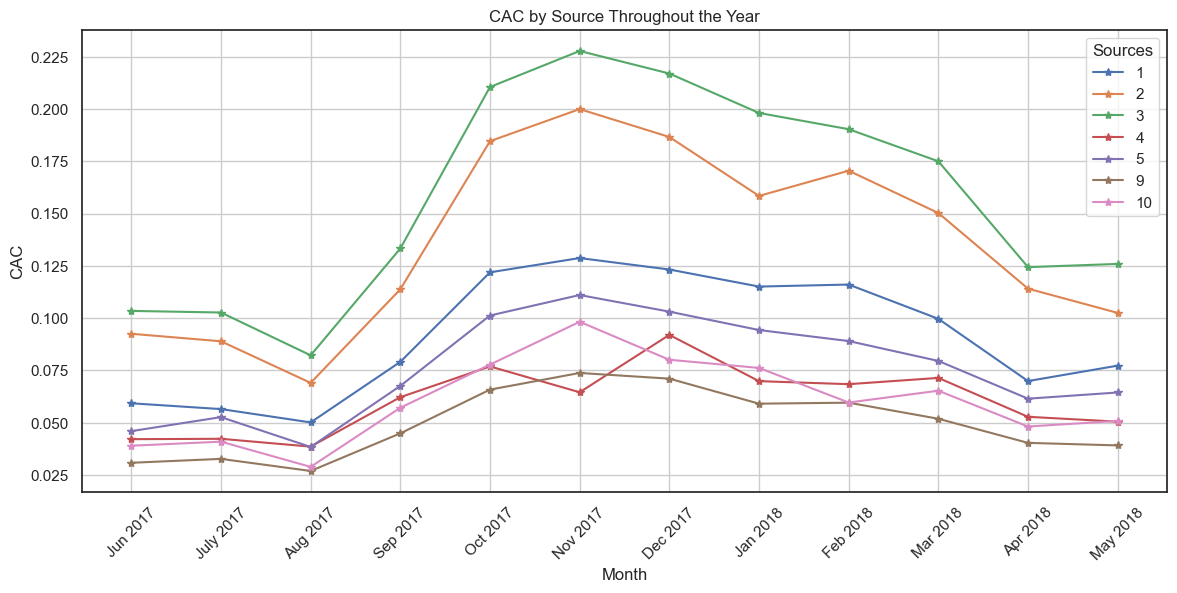

In [39]:
# Creación de gráfico de costos por fuente a lo largo del año
costs_by_source_in_time = costs.groupby(['session_year','session_month','source_id']).agg({'costs':'sum'}).reset_index()
costs_by_source_in_time.sort_values(by=['session_year','session_month'], inplace=True)
costs_by_source_in_time = costs_by_source_in_time.merge(customers[['source_id','n_customers']], on='source_id')
costs_by_source_in_time['cac_by_source'] = costs_by_source_in_time['costs'] / costs_by_source_in_time['n_customers']

# Graficación de el CAC por fuente de marketing a travez del tiempo
fig, ax = plt.subplots(figsize=(14, 6))
costs_cac = costs_by_source_in_time.pivot(index=['session_year','session_month'], columns='source_id', values ='cac_by_source').reset_index()
costs_cac.iloc[:,2:].plot(kind='line', 
                          title='CAC by Source Throughout the Year',
                          rot=45, 
                          marker='*',
                          ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Sources')
plt.ylabel('CAC')
plt.xlabel('Month')
plt.grid()
plt.show()

Como se observó anteriormente, la fuente 3 es la que recibe mayor inversión para la adquisición de clientes. Por otra parte, es importante resaltar que continúa la tendencia al alza que comienza en el mes de agosto. Esta información se complementará más adelante con las gráficas de resultados de LTV y ROMI, principalmente, ya que por sí sola la métrica de CAC únicamente indica la cantidad de dinero invertido para conseguir un cliente. Sin otro punto de comparación, no sería posible llegar a una conclusión más sólida que la ya mencionada.

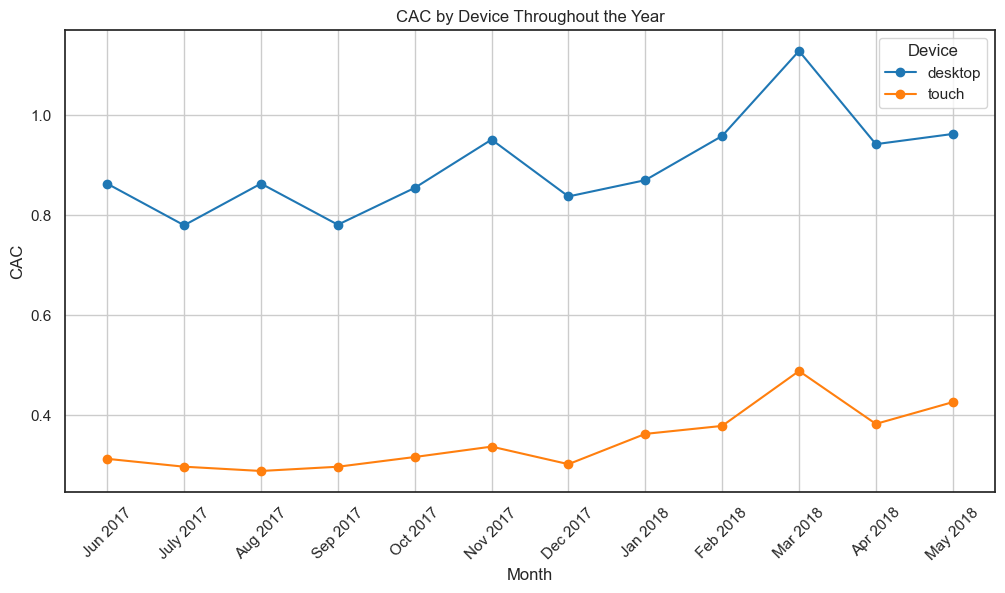

In [40]:
# Agrupación por mes y año del costo por dispositivo
cac_by_devices = costs.groupby(['session_year','session_month','source_id']).agg({'costs':'sum'}).reset_index()
cac_by_devices = cac_by_devices.merge(devices, on=['session_year','session_month','source_id'])
cac_by_devices['cac_device'] = cac_by_devices['n_devices'] / cac_by_devices['costs']
# Graficación del CAC por dispositivo a lo largo del año
fig, ax = plt.subplots(figsize=(12, 6))
pivot_cac_by_devices = cac_by_devices.pivot_table(index=['session_year','session_month'], columns='device', values ='cac_device').reset_index()
pivot_cac_by_devices.iloc[:,2:].plot(y=['desktop','touch'], 
                                     kind='line', 
                                     title='CAC by Device Throughout the Year',
                                     color=['#1F77B4','#FF7F0E'], 
                                     rot=45, 
                                     marker='o',
                                     ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Device')
plt.ylabel('CAC')
plt.xlabel('Month')
plt.grid()
plt.show()

Como se ha venido mostrando, los dispositivos a los cuales se les da mayor consideración son los denominados desktop. De la misma manera que en el análisis anterior, es evidente que esta categoría de dispositivos ha recibido más recursos y también es la más popular. Sin embargo, esto no significa necesariamente que sea la más rentable. Al inicio del proyecto se observaron varios indicios de que esta categoría no se desempeña de manera óptima; no obstante, hasta contar con la información complementaria no será posible emitir un veredicto final

#### ¿Cuán rentables eran las inversiones?

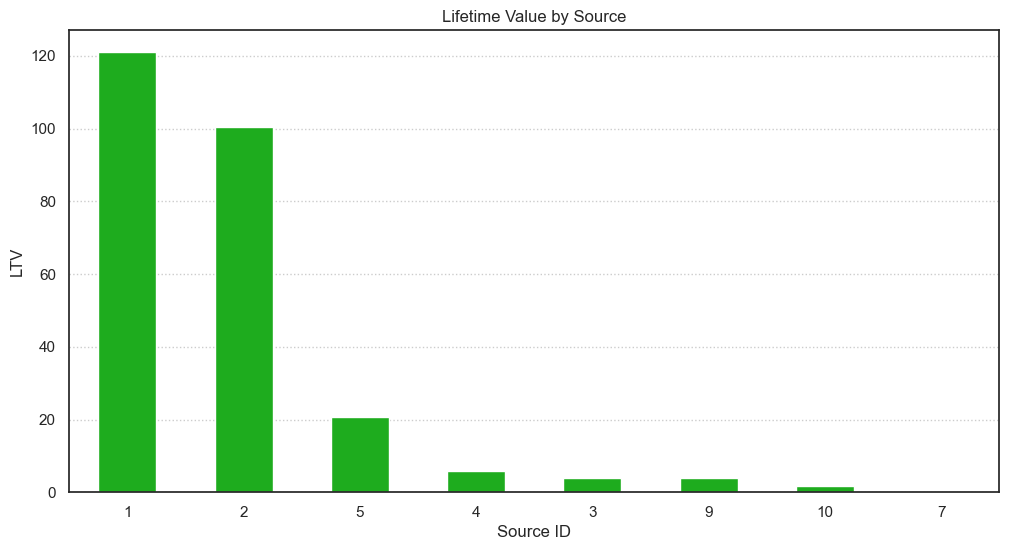

In [41]:
# Cálculo del LTV por fuente
source_id_ltv = visits[['uid','source_id','session_year','session_month']].merge(orders[['uid','revenue']], on='uid')
revenue_by_source = source_id_ltv.groupby('source_id').agg({'revenue':'sum'}).reset_index()
revenue_by_source = revenue_by_source.merge(customers[['source_id','n_customers']], on='source_id')
revenue_by_source['ltv_sources'] = revenue_by_source['revenue'] / revenue_by_source['n_customers']
revenue_by_source.sort_values(by='ltv_sources', ascending=False, inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
revenue_by_source.plot(x='source_id', 
                       y='ltv_sources', 
                       kind='bar', 
                       title='Lifetime Value by Source', 
                       color="#1EAC1E",
                       rot=0,
                       ax=ax)
plt.grid(axis='y', linestyle=':')
plt.legend().remove()
plt.ylabel('LTV')
plt.xlabel('Source ID')
plt.show()

De acuerdo con la tabla, la fuente de marketing número 1 es la que genera mayores ganancias provenientes de los clientes. Muy probablemente se trate de un canal bastante popular, posiblemente relacionado con redes sociales u otro medio que facilite convencer a los clientes para que realicen la compra de boletos.

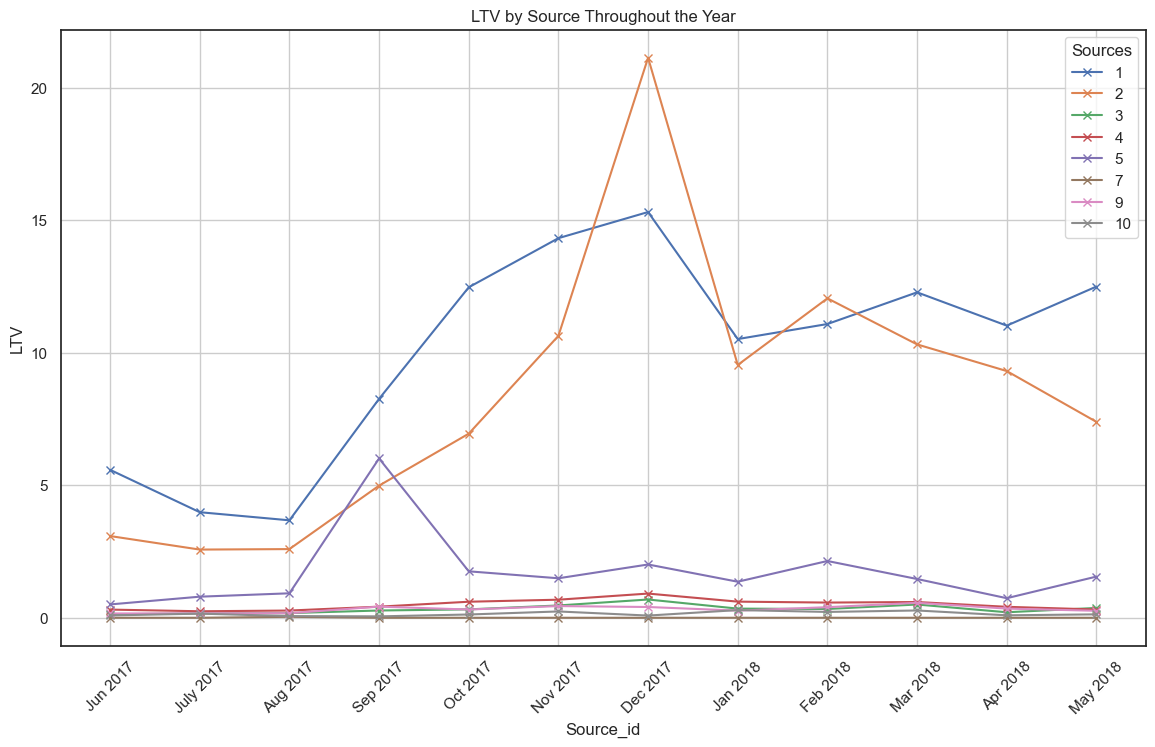

In [50]:
# Agrupación de datos por mes y año y fuente de markeintg
source_id_ltv = visits[['uid','source_id','session_year','session_month']].merge(orders[['uid','revenue']], on='uid')
revenue_by_time = source_id_ltv.groupby(['session_year','session_month','source_id']).agg({'revenue':'sum'}).reset_index()
revenue_by_time.sort_values(by=['session_year','session_month'], inplace=True)
revenue_by_time = revenue_by_time.merge(customers[['source_id','n_customers']], on='source_id')
revenue_by_time['ltv_by_source'] = (revenue_by_time['revenue'] / revenue_by_time['n_customers'])

# Graficación del LTV por fuentes de marketing
fig, ax = plt.subplots(figsize=(14, 8))
costs_ltv = revenue_by_time.pivot(index=['session_year','session_month'], columns='source_id', values='ltv_by_source').reset_index().fillna(0)
costs_ltv.iloc[:,2:].plot(kind='line', 
                          title='LTV by Source Throughout the Year', 
                          rot=45, 
                          marker='x'
                          ,ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Sources')
plt.ylabel('LTV')
plt.xlabel('Source_id')
plt.grid()
plt.show()

De acuerdo con la perspectiva de la gráfica, se observa nuevamente una tendencia en el mes de agosto. Además, la fuente 1 es la que obtiene mayores ganancias. Aunque pudiera parecer que la fuente 2 es la más rentable, un análisis detallado muestra que durante gran parte del año sus ganancias se encuentran por debajo de las de la fuente 1. Solo en momentos muy específicos, como en diciembre de 2017 y febrero de 2018, logra superarla; sin embargo, esto no significa que sea superior en términos generales.

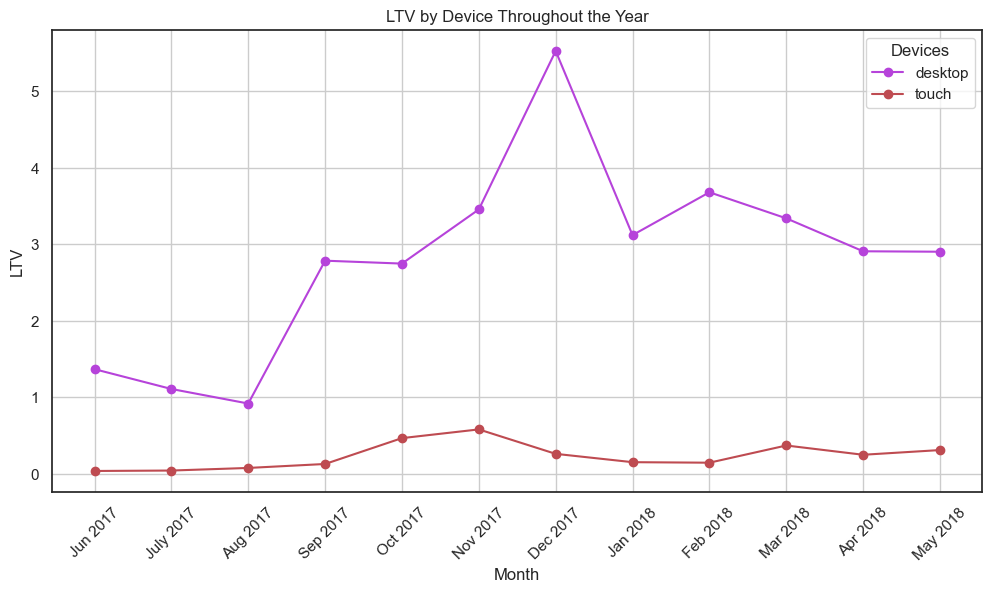

In [43]:
# Agrupación de datos por mes y año y fuente de markeintg
device_ltv = visits[['uid','source_id','session_year','session_month','device']].merge(orders[['uid','revenue']], on='uid')
revenue_by_device = device_ltv.groupby(['session_year','session_month','source_id','device']).agg({'revenue':'sum'}).reset_index()
revenue_by_device.sort_values(by=['session_year','session_month'], inplace=True)
revenue_by_device = revenue_by_device.merge(customers[['source_id','n_customers']], on='source_id')
revenue_by_device['n_customers'] = revenue_by_device['n_customers'].astype('float')
revenue_by_device['ltv_device'] = (revenue_by_device['revenue'] / revenue_by_device['n_customers'])

# Graficación del LTV por fuentes de marketing
fig, ax = plt.subplots(figsize=(12, 6))
costs_ltv_device = revenue_by_device.pivot_table(index=['session_year','session_month'], columns='device', values='ltv_device').reset_index().fillna(0)
costs_ltv_device.iloc[:,2:].plot(kind='line', 
                                 title='LTV by Device Throughout the Year', 
                                 color=["#B643DA","#BE4B51"], 
                                 rot=45, 
                                 marker='o', 
                                 ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Devices')
plt.ylabel('LTV')
plt.xlabel('Month')
plt.grid()
plt.show()

Así como se ha mostrado a lo largo del proyecto, los dispositivos con mayor recaudación son los desktop. Ya sea porque resultan más populares o más cómodos de utilizar, mantienen una alta dominancia frente a los dispositivos touch. Nuevamente se observa una ligera tendencia al alza a partir del mes de agosto.

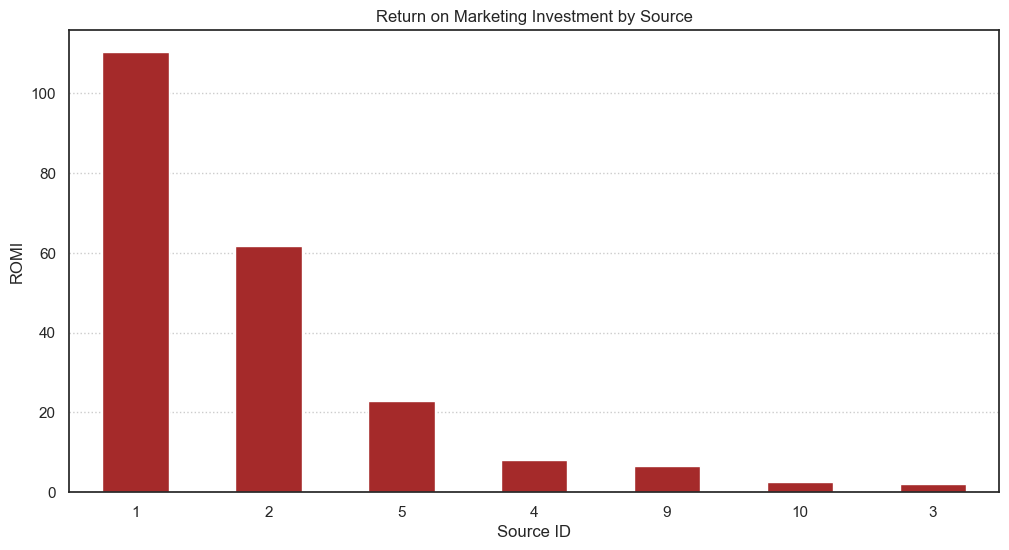

In [44]:
# Agrupación y calculo del ROMI mediante el LTV y CAC
romi_by_source = revenue_by_source.merge(cac_by_source[['source_id','cac_sources']], on='source_id')
romi_by_source['romi_sources'] = romi_by_source['ltv_sources'] / romi_by_source['cac_sources']

# Graficación del ROMI por fuente
fig, ax = plt.subplots(figsize=(12, 6))
romi_by_source.sort_values(by='romi_sources', ascending=False, inplace=True)
romi_by_source.plot(x='source_id', 
                    y='romi_sources', 
                    kind='bar', 
                    title='Return on Marketing Investment by Source',
                    color='brown',
                    rot=0, 
                    ax=ax)
plt.grid(axis='y', linestyle=':')
plt.legend().remove()
plt.ylabel('ROMI')
plt.xlabel('Source ID')
plt.show()


En este punto es donde podemos comprobar si las inversiones y las ganancias obtenidas por cada tipo de fuente han valido la pena. Es curioso que, en este caso, los tres primeros ingresos correspondan a los mismos que en la tabla del LTV, lo que demuestra que efectivamente son redituables, aunque no todos en la misma medida. La fuente 1, a diferencia de la 2 y la 5, muestra en la gráfica que por cada dólar invertido se obtienen $1.2 de regreso, lo que significa un retorno positivo, aunque las ganancias sean limitadas. En contraste, para las otras dos fuentes se observa que la fuente 2 genera aproximadamente $0.6 por cada dólar invertido y la fuente 5 solo $0.25, lo que implica que, si bien no son negativas, la recuperación y las ganancias tardarán en reflejarse.

Por otra parte, entre las fuentes con menor ROMI se destaca la fuente número 3, que presenta el peor retorno de inversión. Su rendimiento es demasiado bajo y, considerando la cantidad de dinero que se le destina, no resulta viable. En cuanto a las demás fuentes (4, 9 y 10), tampoco muestran un nivel de rentabilidad significativo; probablemente no reciben tanta inversión como la fuente 3, pero tampoco generan un capital relevante. Aunque las fuentes con métricas bajas no necesariamente implican pérdidas, tampoco son sostenibles a largo plazo, ya que sería imposible mantener el negocio si el retorno de la inversión tarda demasiado en recuperar el capital.

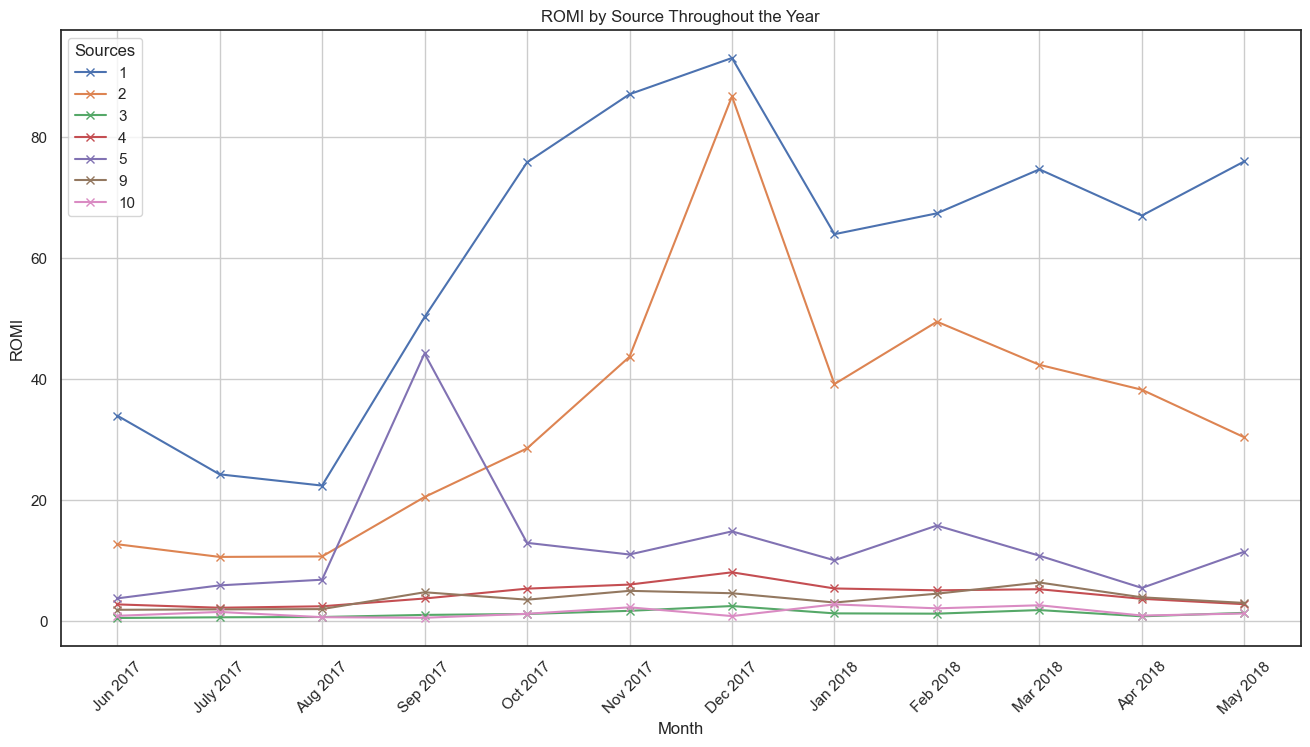

In [48]:
# Agrupación de los datos del LTV y CAC para el cálculo del ROMI
romi_in_time = revenue_by_device.merge(costs_by_source_in_time[['source_id','cac_by_source']], on='source_id', how='outer')
romi_in_time['romi_by_source'] = romi_in_time['ltv_device'] / romi_in_time['cac_by_source']
# Graficación del ROMI a lo largo del año
fig, ax = plt.subplots(figsize=(16, 8))
romi = romi_in_time.pivot_table(index=['session_year','session_month'], columns='source_id', values='romi_by_source').reset_index()
romi.iloc[:,2:].plot(kind='line', 
                     title='ROMI by Source Throughout the Year',
                     rot=45, 
                     marker='x', 
                     ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Sources')
plt.ylabel('ROMI')
plt.xlabel('Month')
plt.grid()
plt.show()

El análisis del ROMI evidencia que, aunque el repunte de agosto marca un punto de recuperación en las ganancias, el verdadero pico ocurre en diciembre de 2017, reflejando una clara estacionalidad vinculada a campañas de fin de año y mayor consumo. La Fuente 1 se consolida como el canal más rentable y consistente, convirtiéndose en el pilar principal de las inversiones de marketing. En contraste, la Fuente 2 muestra un comportamiento más volátil: logra un incremento significativo en diciembre, pero su caída posterior revela menor capacidad de retención. Las demás fuentes mantienen niveles bajos y estables, lo que indica un alcance limitado. En términos estratégicos, es recomendable diversificar los canales para reducir la dependencia de la Fuente 1, optimizar campañas en periodos de alta demanda como diciembre y evaluar la eficiencia relativa de cada fuente para asegurar un crecimiento sostenible en el largo plazo.

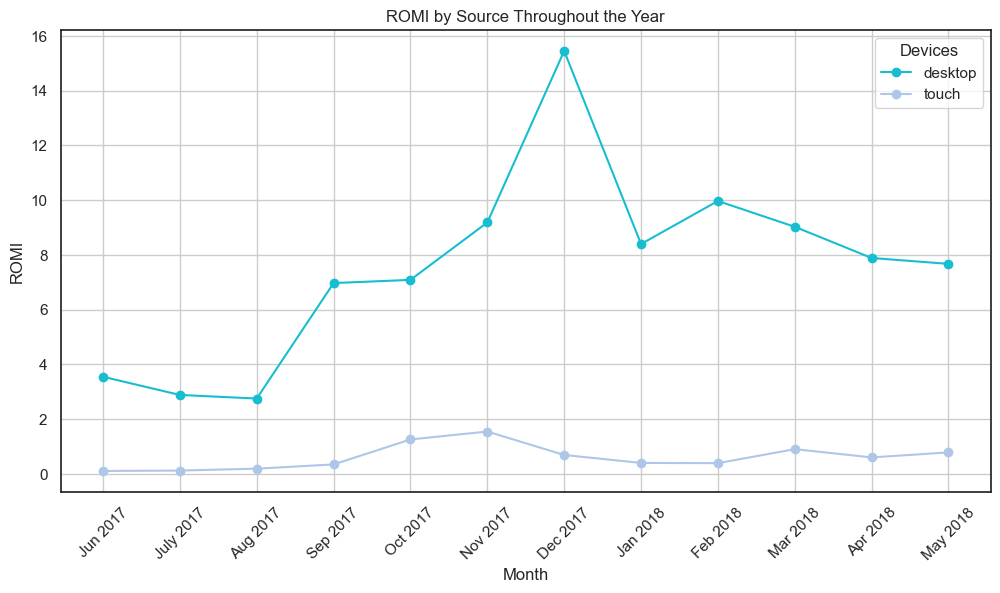

In [46]:
# Agrupación y calculo del ROMI mediante el LTV y CAC por dispositivo
romi_by_device = revenue_by_device.merge(cac_by_devices[['source_id','cac_device']], on='source_id', how='outer')
romi_by_device['romi_device'] = romi_by_device['ltv_device'] / romi_by_device['cac_device']

# Graficación del ROMI a lo largo del año
fig, ax = plt.subplots(figsize=(12, 6))
romi_pivot = romi_by_device.pivot_table(index=['session_year','session_month'], columns='device', values='romi_device').reset_index()
romi_pivot.plot(y=['desktop','touch'], 
                kind='line', 
                title='ROMI by Source Throughout the Year',
                rot=45, 
                color=['#17BECF','#AEC7E8'], 
                marker='o', 
                ax=ax)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.legend(title='Devices')
plt.ylabel('ROMI')
plt.xlabel('Month')
plt.grid()
plt.show()

Además de señalar el dominio de los dispositivos desktop durante todo el año, se puede complementar el análisis destacando que el pico más significativo ocurre en diciembre de 2017, donde el rendimiento de desktop alcanza su máximo y marca una diferencia muy amplia frente a la categoría touch, que se mantiene estable y en niveles bajos. Esto sugiere que las campañas o la estacionalidad de fin de año tienen un impacto mucho mayor en usuarios de escritorio, mientras que los dispositivos móviles apenas muestran variaciones.

En términos estratégicos, el hallazgo refuerza la idea de que las inversiones en marketing enfocadas en desktop generan retornos más sólidos y consistentes, pero también abre la oportunidad de explorar cómo potenciar la categoría touch, ya que su bajo desempeño podría deberse a limitaciones en la experiencia de compra o en la captación de clientes por ese canal. De esta manera, el análisis no solo confirma la preferencia por desktop, sino que también invita a evaluar acciones para equilibrar y aprovechar mejor ambos dispositivos.

## ✅ Conlusiones

- El dispositivo desktop es el predilecto de los usuarios, concentrando la mayor cantidad de visitas, captación de clientes e ingresos. Esto se refleja en métricas como CAC, LTV y ROMI, donde obtiene los valores más altos. Sin embargo, también es el dispositivo en el que los usuarios tardan más en convertirse, posiblemente por factores como diseño de interfaces o problemas técnicos. Por su parte, los dispositivos móviles, aunque menos populares y con menor retorno de inversión, muestran un potencial no explotado: al inicio del proyecto la conversión fue más rápida y las ganancias promedio más altas, lo que sugiere que una mayor inversión y optimización en marketing móvil podría mejorar su desempeño.

- En la mayoría de las métricas se observa un repunte a partir de agosto, que se extiende por 9 a 10 meses. Este patrón indica una temporada de mayor inversión y ganancias, lo que hace recomendable analizar si se repite en otros años para anticipar estrategias de marketing que maximicen resultados en ese periodo. Además, la baja retención de usuarios obliga a incrementar el gasto en marketing para evitar fugas, por lo que diseñar campañas específicas para fidelización sería clave.

- El análisis del ROMI por fuente de marketing sugiere la siguiente distribución óptima del presupuesto:

  - Source 1: 51.53%
  - Source 2: 28.79%
  - Source 5: 10.67%
  - Source 4: 3.8%
  - Source 9: 3.1%
  - Source 10: 1.2%
  - Source 3: 1%

- Las tres principales fuentes (1, 2 y 5) concentran la mayor rentabilidad y deberían recibir la mayor parte de la inversión. En cambio, las fuentes con retornos marginales (3, 4, 9 y 10) no justifican mantener porcentajes de inversión tan bajos. Sería más viable reducir o eliminar esas fuentes y redistribuir el presupuesto hacia las más efectivas, aunque también cabe la posibilidad de mejorar sus canales de marketing si se busca diversificación.